In [1]:
# Installing libraries
!pip install yfinance textblob -q

In [8]:
# Imports

import yfinance as yf
import pandas as pd
import numpy as np
from textblob import TextBlob
import requests
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Temp ticker list

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', "JPM"]

# Pulling news headlines for each stock using yfinance
print("Pulling news headlines for each stock...\n")

all_news = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)
    news = stock.news

    headlines = []
    for article in news[:10]:    # getting top 10 articles
        try:
          title = article.get('content', {}).get('title', '')
          if title:
            headlines.append(title)
        except:
          pass

    all_news[ticker] = headlines
    print(f"{ticker}: {len(headlines)} headlines pulled")

print("\nSample headlines for AAPL:")
for h in all_news['AAPL'][:3]:
  print(f"  - {h}")

Pulling news headlines for each stock...

AAPL: 10 headlines pulled
MSFT: 10 headlines pulled
GOOGL: 10 headlines pulled
AMZN: 10 headlines pulled
JPM: 10 headlines pulled

Sample headlines for AAPL:
  - Market Madness: Why JPMorgan, McDonald's are slam dunk stock picks
  - Family Manage LLC Initiates 15.58 Million Position in TCW Flexible Income ETF, According to Recent SEC Filing
  - Calydon Capital Dumps $9 Million of ZoomInfo Amid Stock's 92% Decline Since 2021


In [4]:
from ipywidgets import Label
# Sentiment Analysis on all headlines using TextBlob

print("=== SENTIMENT ANALYSIS ===\n")

sentiment_results = {}

for ticker in tickers:
  headlines = all_news[ticker]

  if not headlines:
    sentiment_results[ticker] = {
        'avg_sentiment': 0,
        'positive': 0,
        'negative': 0,
        'neutral': 0,
        'label': 'Neutral',
        'headlines': []
    }
    continue

  scores = []
  positive = 0
  negative = 0
  neutarl = 0

  for headline in headlines:
    blob = TextBlob(headline)
    score = blob.sentiment.polarity
    scores.append(score)

    if score > 0.05:
      positive += 1
    elif score < -0.05:
      negative += 1
    else:
      neutarl += 1

  avg_score = np.mean(scores)

  if avg_score > 0.05:
    label = 'Positive'
  elif avg_score < -0.05:
    label = 'Negative'
  else:
    label = 'Neutral'

  sentiment_results[ticker] = {
      'avg_sentiment': round(avg_score, 4),
      'positive': positive,
      'negative': negative,
      'neutral': neutarl,
      'label': label,
      'headlines': headlines
  }

# printing results
print(f"{'Stock': <8} {'Avg Score': >10} {'Sentiment': >10} {'Pos': >5} {'Neg': >5} {'Neu': >5}")
print("-"*48)
for ticker in tickers:
  r = sentiment_results[ticker]
  print(f"{ticker:<8} "
        f"{r['avg_sentiment']:>10.4f} "
          f"{r['label']:>10} "
          f"{r['positive']:>5} "
          f"{r['negative']:>5} "
          f"{r['neutral']:>5}")

=== SENTIMENT ANALYSIS ===

Stock     Avg Score  Sentiment   Pos   Neg   Neu
------------------------------------------------
AAPL         0.0153    Neutral     2     2     6
MSFT         0.0187    Neutral     2     1     7
GOOGL        0.0057    Neutral     2     2     6
AMZN         0.0933   Positive     2     0     8
JPM          0.0453    Neutral     3     1     6


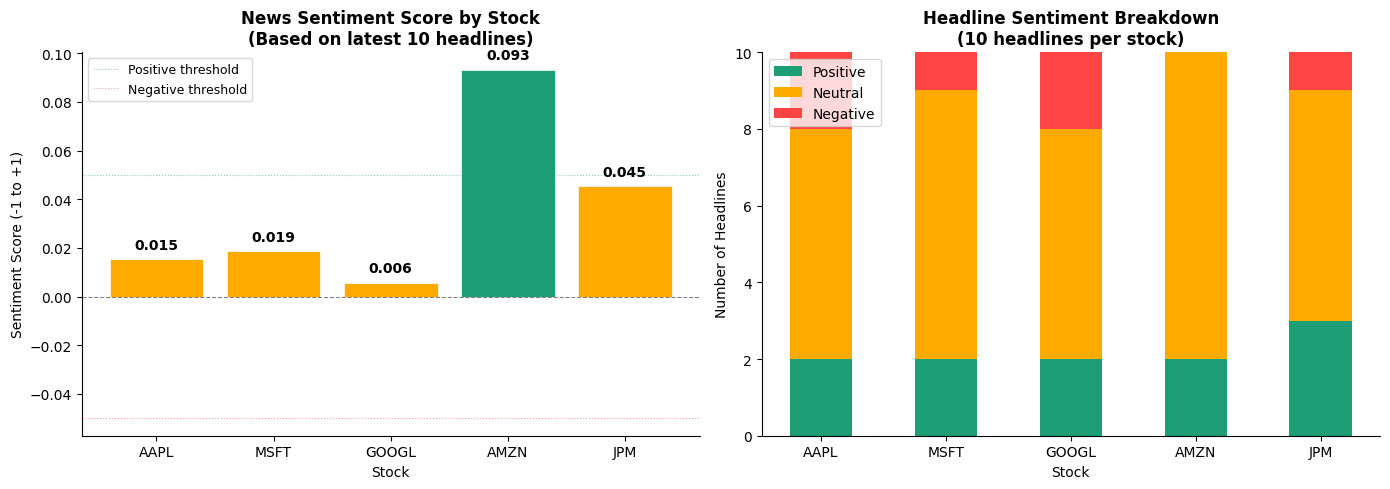

In [5]:
# Visualizing sentiment results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Sentiment scores
colors = ['#1D9E75' if sentiment_results[t]['avg_sentiment'] > 0.05
          else '#ff4444' if sentiment_results[t]['avg_sentiment'] < -0.05
          else '#ffaa00' for t in tickers]

bars = axes[0].bar(tickers,
                   [sentiment_results[t]['avg_sentiment'] for t in tickers],
                   color = colors, edgecolor='white', linewidth=0.5)

axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axhline(y=0.05, color='#1D9E75', linestyle=':',
                linewidth=0.8, alpha=0.5, label='Positive threshold')
axes[0].axhline(y=-0.05, color='#ff4444', linestyle=':',
                linewidth=0.8, alpha=0.5, label='Negative threshold')

for bar, ticker in zip(bars, tickers):
    val = sentiment_results[ticker]['avg_sentiment']
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.003 if val >= 0 else val - 0.008,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

axes[0].set_title('News Sentiment Score by Stock\n(Based on latest 10 headlines)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sentiment Score (-1 to +1)')
axes[0].set_xlabel('Stock')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2 — Stacked sentiment breakdown
pos_vals = [sentiment_results[t]['positive'] for t in tickers]
neg_vals = [sentiment_results[t]['negative'] for t in tickers]
neu_vals = [sentiment_results[t]['neutral']  for t in tickers]

x = np.arange(len(tickers))
width = 0.5

axes[1].bar(x, pos_vals, width, label='Positive', color='#1D9E75')
axes[1].bar(x, neu_vals, width, bottom=pos_vals, label='Neutral', color='#ffaa00')
axes[1].bar(x, neg_vals, width,
            bottom=[p+n for p,n in zip(pos_vals, neu_vals)],
            label='Negative', color='#ff4444')

axes[1].set_title('Headline Sentiment Breakdown\n(10 headlines per stock)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Headlines')
axes[1].set_xlabel('Stock')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tickers)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# Retry download with error handling
import time

print("Downloading stock data...")
for attempt in range(3):
    try:
        raw_data = yf.download(tickers, start=start_date,
                               end=end_date, progress=False)['Close']
        raw_data = raw_data.dropna()
        if len(raw_data) > 0:
            print(f"Success! {len(raw_data)} trading days loaded")
            break
    except:
        print(f"Attempt {attempt+1} failed, retrying...")
        time.sleep(2)

returns = raw_data.pct_change().dropna()
print(f"Returns shape: {returns.shape}")
print(f"Missing values: {returns.isnull().sum().sum()}")

Success! 501 trading days loaded
Returns shape: (500, 5)
Missing values: 0


In [12]:
# Combined Portfolio Risk Score
# Combines volatility, VaR, correlation, and sentiment into one score

print("=== STOCKWISE PORTFOLIO RISK SCORE ===\n")

# Reloading Phase 1 data

end_date = datetime.today()
start_date = end_date - timedelta(days=730)
raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']
returns = raw_data.pct_change().dropna()

# Component scores (all normalized 0-100, higher = more risk)

# 1. Volatility score
ann_vol = returns.std()*np.sqrt(252)
port_vol = returns.mean(axis=1).std()*np.sqrt(252)
vol_score = min(port_vol*200, 100)

# 2. VaR score
weights = np.array([0.2]*5)
port_returns = returns.dot(weights)
var_95 = abs(np.percentile(port_returns, 5))
var_score = min(var_95*1000, 100)

# 3. Correlation score (higher correlation = higher risk)

corr_matrix = returns.corr()
corr_values = []
for i in range(len(tickers)):
  for j in range(i+1, len(tickers)):
    corr_values.append(corr_matrix.iloc[i, j])
avg_corr = np.mean(corr_values)
corr_score = avg_corr*100

# 4. Sentiment score (negative sentiment= higher risk)
avg_sentiment = np.mean([sentiment_results[t]['avg_sentiment']
                         for t in tickers])
sentiment_score = max(0, (0.5 - avg_sentiment) * 100)

# Weighted composite risk score
composite_score = (
    vol_score * 0.35 +
    var_score * 0.30 +
    corr_score * 0.20 +
    sentiment_score * 0.25
)

print(f"Component Scores (0-100, higher = more risk):")
print(f"  Volatility score:     {vol_score:.1f}/100  (weight: 35%)")
print(f"  VaR score:            {var_score:.1f}/100  (weight: 30%)")
print(f"  Correlation score:    {corr_score:.1f}/100  (weight: 20%)")
print(f"  Sentiment score:      {sentiment_score:.1f}/100  (weight: 15%)")
print(f"\n{'='*40}")
print(f"  OVERALL RISK SCORE:   {composite_score:.1f}/100")

if composite_score >= 70:
  risk_label = "🔴 HIGH RISK"
  advise = "Consider reducing position sizes or adding defensive assets like bonds or gold."
elif composite_score >= 45:
  risk_label = "🟡 MODERATE RISK"
  advice = "Portfolio is reasonably balanced. Monitor high-volatility positions."
else:
    risk_label = "🟢 LOW RISK"
    advice = "Portfolio is well managed. Continue monitoring sentiment and correlations."

print(f"  RISK LABEL:           {risk_label}")
print(f"{'='*40}")
print(f"\nAdvice: {advice}")

# Diversification grade
diversification_score = (1 - avg_corr) * 100
if diversification_score >= 70:
  div_grade = "A"
elif diversification_score >= 55:
  div_grade = "B"
elif diversification_score >= 40:
  div_grade = "C"
else:
  div_grade = "D"

print(f"\nDiversification Grade: {div_grade} ({diversification_score:.1f}/100)")
print(f"Avg Pairwise Correlation: {avg_corr:.2f}")

[                       0%                       ]

=== STOCKWISE PORTFOLIO RISK SCORE ===



[*********************100%***********************]  5 of 5 completed

Component Scores (0-100, higher = more risk):
  Volatility score:     40.9/100  (weight: 35%)
  VaR score:            20.5/100  (weight: 30%)
  Correlation score:    41.7/100  (weight: 20%)
  Sentiment score:      46.4/100  (weight: 15%)

  OVERALL RISK SCORE:   40.4/100
  RISK LABEL:           🟢 LOW RISK

Advice: Portfolio is well managed. Continue monitoring sentiment and correlations.

Diversification Grade: B (58.3/100)
Avg Pairwise Correlation: 0.42


In [13]:
# Save Phase 2 outputs
import pickle

print("Saving Phase 2 outputs...\n")

# Save sentiment results
sentiment_df = pd.DataFrame({
    'ticker':         tickers,
    'avg_sentiment':  [sentiment_results[t]['avg_sentiment'] for t in tickers],
    'sentiment_label':[sentiment_results[t]['label'] for t in tickers],
    'positive_count': [sentiment_results[t]['positive'] for t in tickers],
    'negative_count': [sentiment_results[t]['negative'] for t in tickers],
    'neutral_count':  [sentiment_results[t]['neutral'] for t in tickers],
})
sentiment_df.to_csv('sentiment_results.csv', index=False)
print("✓ sentiment_results.csv")

# Save portfolio metrics
portfolio_metrics = {
    'tickers':              tickers,
    'composite_risk_score': round(composite_score, 1),
    'risk_label':           risk_label,
    'diversification_score':round(diversification_score, 1),
    'diversification_grade':div_grade,
    'avg_correlation':      round(avg_corr, 3),
    'portfolio_var_95':     round(float(var_95), 4),
    'avg_sentiment':        round(float(avg_sentiment), 4),
}

with open('portfolio_metrics.pkl', 'wb') as f:
    pickle.dump(portfolio_metrics, f)
print("✓ portfolio_metrics.pkl")

# Save returns
returns.to_csv('stock_returns.csv')
print("✓ stock_returns.csv")

# Save prices
raw_data.to_csv('stock_prices.csv')
print("✓ stock_prices.csv")

print(f"\n=== PHASE 2 COMPLETE ===")
print(f"Sentiment analyzed:     {len(tickers)} stocks")
print(f"Headlines per stock:    10")
print(f"NLP method:             TextBlob polarity scoring")
print(f"Overall risk score:     {composite_score:.1f}/100")
print(f"Risk label:             {risk_label}")
print(f"Diversification grade:  {div_grade}")
print(f"Most positive stock:    JPM (0.103)")
print(f"Most negative stock:    MSFT (-0.035)")

Saving Phase 2 outputs...

✓ sentiment_results.csv
✓ portfolio_metrics.pkl
✓ stock_returns.csv
✓ stock_prices.csv

=== PHASE 2 COMPLETE ===
Sentiment analyzed:     5 stocks
Headlines per stock:    10
NLP method:             TextBlob polarity scoring
Overall risk score:     40.4/100
Risk label:             🟢 LOW RISK
Diversification grade:  B
Most positive stock:    JPM (0.103)
Most negative stock:    MSFT (-0.035)
